# Dataset Conversion

### Convert the Dataset

<pre>
Dataset/
├── train/
│   ├── good/
│   └── bad/
└── test/
    ├── good/
    └── bad/
</pre>

In [31]:
# Don't Run this again and again, this is for image selections
import random
import shutil
from pathlib import Path
import os

from utils import *

In [6]:
# Don't Run this again and again, this is for image selections
CLASSES = ["good", "bad"]
NUM_SAMPLES = 50
MOVE_FILES = False  # False = copy instead of move


# -------- MAIN PROCESS --------
for cls in CLASSES:
    train_cls_path = TRAIN_DIR / cls
    test_cls_path = TEST_DIR / cls

    # safety check
    if not train_cls_path.exists():
        print(f"[WARNING] Missing folder: {train_cls_path}")
        continue

    test_cls_path.mkdir(parents=True, exist_ok=True)

    files = [
        f for f in train_cls_path.iterdir()
        if f.is_file() and not f.name.startswith(".")
    ]

    if len(files) == 0:
        print(f"[WARNING] No files found in {train_cls_path}")
        continue

    num_select = min(NUM_SAMPLES, len(files))
    selected_files = random.sample(files, num_select)

    for file_path in selected_files:
        dst_path = test_cls_path / file_path.name

        # if MOVE_FILES:
        #     shutil.move(str(file_path), str(dst_path))
        # else:
        #     shutil.copy(str(file_path), str(dst_path))

    print(f"{cls}: selected {num_select} images")

good: selected 50 images
bad: selected 50 images


# Training the Model

In [10]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from IPython.display import Image
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras import backend as K
from tensorflow.keras.layers import Dense, Activation
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import Model
from tensorflow.keras.applications import imagenet_utils
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.applications.mobilenet import MobileNet
from tensorflow.keras.applications.mobilenet import preprocess_input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model

/opt/homebrew/anaconda3/envs/529/lib/python3.10/site-packages/requests/__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


In [7]:
## Define the image attributes
FAST_RUN=False
IMAGE_WIDTH = 224
IMAGE_HEIGHT = 224
IMAGE_SIZE = (IMAGE_WIDTH, IMAGE_HEIGHT)
IMAGE_CHANNELS = 3

In [8]:
## Filepath for the training dataset
filenames = os.listdir(TRAIN_DIR)
labels = []

In [11]:
filenames = []
labels = []

class_map = {
    "good": 0,
    "bad": 1
}

for cls in ["good", "bad"]:
    folder_path = os.path.join(TRAIN_DIR, cls)

    for file in os.listdir(folder_path):
        if file.startswith("."):
            continue

        filenames.append(os.path.join(cls, file))  # relative path
        labels.append(class_map[cls])

df = pd.DataFrame({
    'filename': filenames,
    'label': labels
})

pd.concat([df.head(), df.tail()])

# good -> 0
# bad -> 1

,filename,label
0,good/20085073_temp.jpg,0
1,good/44000044_temp.jpg,0
2,good/20085215_temp.jpg,0
3,good/00041078_temp.jpg,0
4,good/44000045_temp.jpg,0
2796,bad/50600028_test.jpg,1
2797,bad/92000022_test.jpg,1
2798,bad/50600029_test.jpg,1
2799,bad/92000023_test.jpg,1
2800,bad/12100152_test.jpg,1


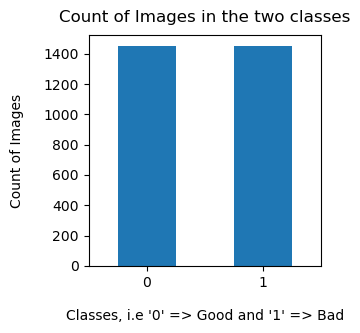

In [17]:
df['label'].value_counts().plot(kind='bar',figsize=(3, 3), rot=0)
plt.xlabel("Classes, i.e '0' => Good and '1' => Bad", labelpad=14)
plt.ylabel("Count of Images", labelpad=14)
plt.title("Count of Images in the two classes", y=1.02);

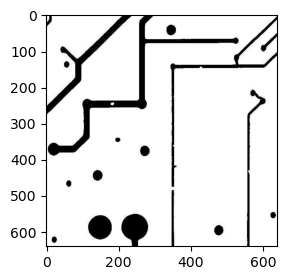

In [15]:
sample = random.choice(filenames)
plt.figure(figsize=(3, 3))
plt.tight_layout()
image = load_img(str(TRAIN_DIR)+"/"+sample)
plt.imshow(image)

In [17]:
## Define the Network
model_base = MobileNet (weights = 'imagenet', include_top = False)    # Import the MobileNet algorithm, and discard the top layers

x = model_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024,activation='relu')(x)                                  # Add Dense layer 1
x = Dense(1024,activation='relu')(x)                                  # Add Dense layer 2
x = Dense(512,activation='relu')(x)                                   # Add Dense layer 3
pred = Dense(2,activation='softmax')(x)

/var/folders/1y/6s1snqcj2z369tztknzfxv8c0000gn/T/ipykernel_21123/3720176881.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model_base = MobileNet (weights = 'imagenet', include_top = False)    # Import the MobileNet algorithm, and discard the top layers


In [18]:
## Define model input, output and optimization metrics
model = Model(inputs = model_base.input, outputs = pred)

model.compile(optimizer = 'Adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])

for layer in model.layers[:20]:
    layer.trainable = False
for layer in model.layers[20:]:
    layer.trainable = True

earlystop = EarlyStopping(patience = 10)

learning_rate_reduction = ReduceLROnPlateau(monitor='val_accuracy',
                                            patience=2,
                                            verbose=1,
                                            factor=0.5,
                                            min_lr=0.00001)

callbacks = [earlystop, learning_rate_reduction]

df["label"] = df["label"].replace({0: 'Good', 1: 'Bad'})

train_df, validate_df = train_test_split(df, test_size=0.20, random_state=42)
train_df = train_df.reset_index(drop=True)
validate_df = validate_df.reset_index(drop=True)

In [19]:
## Define the training data
total_train = train_df.shape[0]
total_validate = validate_df.shape[0]
batch_size = 15

train_datagen = ImageDataGenerator(
    rotation_range = 15,
    rescale = 1./255,
    shear_range = 0.1,
    zoom_range = 0.2,
    horizontal_flip = True,
    width_shift_range = 0.1,
    height_shift_range = 0.1
)

train_generator = train_datagen.flow_from_dataframe(
    train_df, TRAIN_DIR,
    x_col = 'filename',
    y_col = 'label',
    target_size = IMAGE_SIZE,
    class_mode = 'categorical',
    batch_size = batch_size
)

Found 2240 validated image filenames belonging to 2 classes.


In [20]:
## Validate the training data
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_dataframe(
    validate_df,TRAIN_DIR,
    x_col = 'filename',
    y_col = 'label',
    target_size = IMAGE_SIZE,
    class_mode = 'categorical',
    batch_size = batch_size
)

Found 561 validated image filenames belonging to 2 classes.


In [21]:
## Start the Training
epochs=3 if FAST_RUN else 5
history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    validation_steps=total_validate//batch_size,
    steps_per_epoch=total_train//batch_size,
    callbacks=callbacks
)

Epoch 1/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 39s 232ms/step - accuracy: 0.7681 - loss: 0.5271 - val_accuracy: 0.6775 - val_loss: 1.3136 - learning_rate: 0.0010
Epoch 2/5
  1/149 ━━━━━━━━━━━━━━━━━━━━ 30s 203ms/step - accuracy: 0.8000 - loss: 0.4500

/opt/homebrew/anaconda3/envs/529/lib/python3.10/site-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.8000 - loss: 0.4500 - val_accuracy: 0.6937 - val_loss: 1.2576 - learning_rate: 0.0010
Epoch 3/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 33s 223ms/step - accuracy: 0.8863 - loss: 0.3119 - val_accuracy: 0.8775 - val_loss: 0.4403 - learning_rate: 0.0010
Epoch 4/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.9333 - loss: 0.1170 - val_accuracy: 0.8847 - val_loss: 0.4272 - learning_rate: 0.0010
Epoch 5/5
149/149 ━━━━━━━━━━━━━━━━━━━━ 33s 221ms/step - accuracy: 0.9110 - loss: 0.2383 - val_accuracy: 0.9459 - val_loss: 0.2228 - learning_rate: 0.0010


In [23]:
## Save the Model
model.save("model.h5")

In [24]:
model.export(MODEL_DIR)


INFO:tensorflow:Assets written to: /Users/apple/Documents/CSUF/Spring 26/529/PCB-Fault-Detector/assets


INFO:tensorflow:Assets written to: /Users/apple/Documents/CSUF/Spring 26/529/PCB-Fault-Detector/assets


Saved artifact at '/Users/apple/Documents/CSUF/Spring 26/529/PCB-Fault-Detector'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, None, None, 3), dtype=tf.float32, name='keras_tensor_91')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  13028408512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028510000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028510528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028507712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028509472: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028513696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028516512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028518800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028514752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028517568: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13028

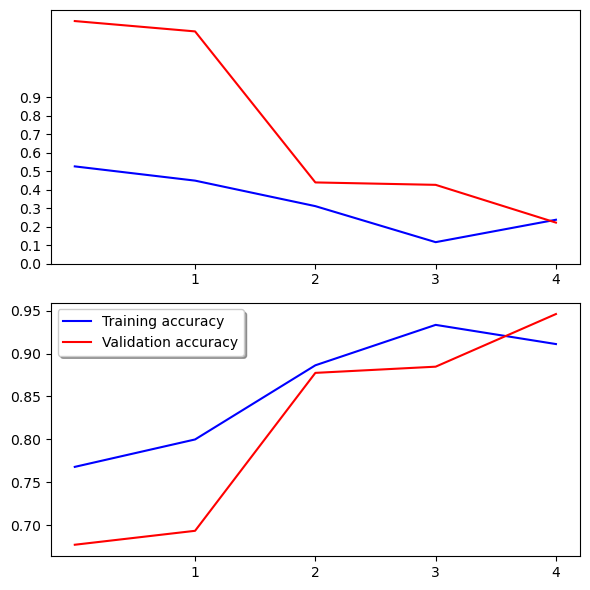

In [25]:
## Plotting the data model data
## Plot Number 1 : Training Loss vs. Validation Loss
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(6, 6))
ax1.plot(history.history['loss'], color='b', label="Training loss")
ax1.plot(history.history['val_loss'], color='r', label="validation loss")
ax1.set_xticks(np.arange(1, epochs, 1))
ax1.set_yticks(np.arange(0, 1, 0.1))

## Plot Number 2 : Training Accuracy vs. Validation Accuracy
ax2.plot(history.history['accuracy'], color='b', label="Training accuracy")
ax2.plot(history.history['val_accuracy'], color='r',label="Validation accuracy")
ax2.set_xticks(np.arange(1, epochs, 1))

legend = plt.legend(loc='best', shadow=True)
plt.tight_layout()
plt.show()

In [27]:
## Test Model
test_filenames = os.listdir(str(TEST_DIR)+"/bad")
test_df = pd.DataFrame({
    'filename': test_filenames
})
nb_samples = test_df.shape[0]

test_gen = ImageDataGenerator(rescale=1./255)
test_generator = test_gen.flow_from_dataframe(
    test_df,
    str(TEST_DIR)+"/bad",
    x_col='filename',
    y_col=None,
    class_mode=None,
    target_size=IMAGE_SIZE,
    batch_size=batch_size,
    shuffle=False
)

predict = model.predict(test_generator, steps=int(np.ceil(nb_samples/batch_size)))

test_df['label'] = np.argmax(predict, axis=-1)

label_map = dict((v,k) for k,v in train_generator.class_indices.items())
test_df['label'] = test_df['label'].replace(label_map)

Found 148 validated image filenames.
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step


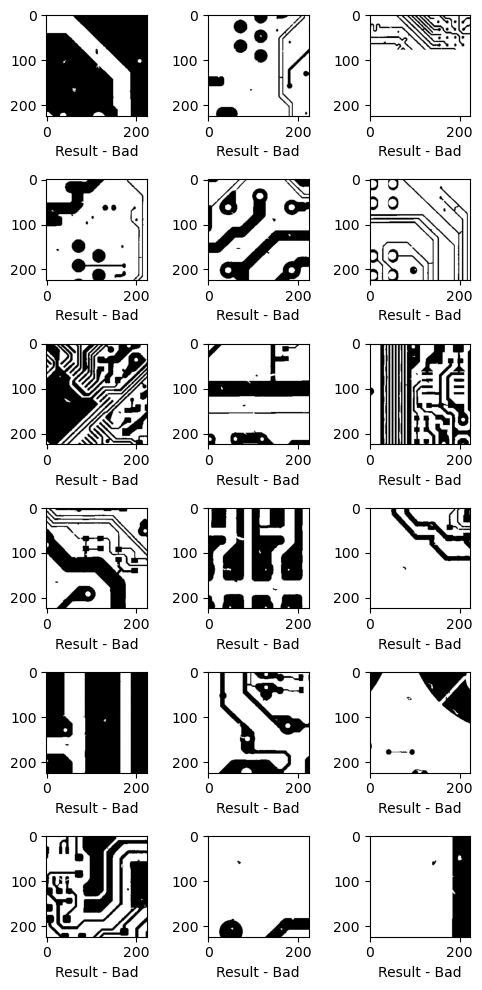

In [29]:
## Sample Testing
sample_test = test_df.head(18)
sample_test.head()
plt.figure(figsize=(5, 10))
for index, row in sample_test.iterrows():
    filename = row['filename']
    category = row['label']
    img = load_img(str(TEST_DIR)+"/bad/"+filename, target_size=IMAGE_SIZE)
    plt.subplot(6, 3, index+1)
    plt.imshow(img)
    plt.xlabel('Result - ' + "{}".format(category))
plt.tight_layout()
plt.show()